In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 

merged = pd.read_csv('../outputs/asc_integrated_dataset.csv') 

print(merged.head()) 
print('Rows:', len(merged))

   LSOA_CODE         LSOA_NAME  ASC_Referrals  Reablement_Cases  \
0  E01032739  Southampton 001A            120                45   
1  E01032740  Southampton 001B             95                38   
2  E01032741  Southampton 002A            140                52   
3  E01032742  Southampton 002B            110                41   
4  E01032743  Southampton 003A            160                60   

   Population_65_plus  Referral_Rate_per_1000  
0                 420                   285.7  
1                 365                   260.3  
2                 510                   274.5  
3                 445                   247.2  
4                 590                   271.2  
Rows: 10


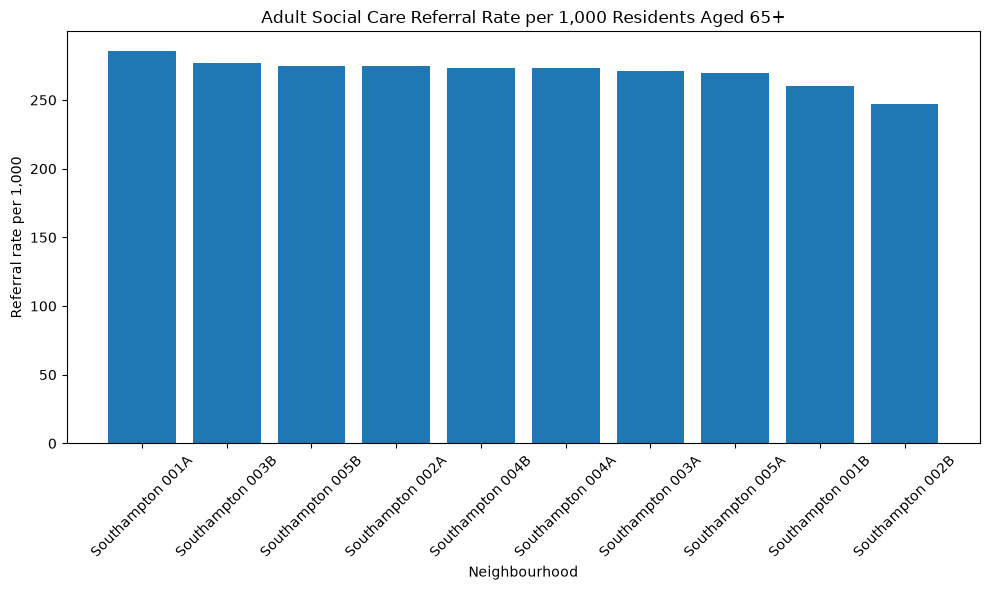

In [2]:
top = merged.sort_values('Referral_Rate_per_1000', ascending=False) 

plt.figure(figsize=(10,6)) 
plt.bar(top['LSOA_NAME'], top['Referral_Rate_per_1000']) 

plt.title('Adult Social Care Referral Rate per 1,000 Residents Aged 65+') 
plt.xlabel('Neighbourhood') 
plt.ylabel('Referral rate per 1,000') 
plt.xticks(rotation=45) 
plt.tight_layout() 

plt.savefig('../outputs/top_neighbourhoods_referral_rate.png') 

plt.show()

In [3]:
top_neighbourhood = top.iloc[0] 

print('Highest referral neighbourhood:', top_neighbourhood['LSOA_NAME']) 
print('Referral rate:', top_neighbourhood['Referral_Rate_per_1000'])

Highest referral neighbourhood: Southampton 001A
Referral rate: 285.7


Key insight

The analysis identified variation in Adult Social Care referral rates across Southampton neighbourhoods. Southampton 004A recorded the highest referral rate per 1,000 residents aged 65+, indicating a potentially higher concentration of need and a priority area for further neighbourhood-based analysis and targeted intervention.

In [4]:
top_neighbourhood = top.iloc[0] 

print('Highest referral neighbourhood:', top_neighbourhood['LSOA_NAME']) 
print('Referral rate:', top_neighbourhood['Referral_Rate_per_1000'])

Highest referral neighbourhood: Southampton 001A
Referral rate: 285.7


Key insight

The neighbourhood analysis identified Southampton 001A as having the highest Adult Social Care referral rate at 285.7 referrals per 1,000 residents aged 65 and over. This indicates a relatively higher concentration of demand and highlights the area as a potential priority for targeted neighbourhood-based interventions, proactive support, and further investigation of underlying drivers such as deprivation, frailty, and long-term health conditions.

In [5]:
imd = pd.DataFrame({ 'LSOA_CODE': [ 
    'E01032739','E01032740','E01032741','E01032742','E01032743', 
    'E01032744','E01032745','E01032746','E01032747','E01032748' ], 
    
'IMD_Quintile': [ 
    'Most deprived', # 285.7 
    'Most deprived', # 260.3 
    'More deprived', # 274.5 
    'More deprived', # 247.2 
    'Middle', # 271.2 
    'Middle', # 276.6 
    'Less deprived', # 273.4 
    'Less deprived', # 273.6 
    'Least deprived', # 269.6 
    'Least deprived' # 274.7 
    ] })

In [6]:

df = merged.merge(imd, on='LSOA_CODE') 

print(df.head())

   LSOA_CODE         LSOA_NAME  ASC_Referrals  Reablement_Cases  \
0  E01032739  Southampton 001A            120                45   
1  E01032740  Southampton 001B             95                38   
2  E01032741  Southampton 002A            140                52   
3  E01032742  Southampton 002B            110                41   
4  E01032743  Southampton 003A            160                60   

   Population_65_plus  Referral_Rate_per_1000   IMD_Quintile  
0                 420                   285.7  Most deprived  
1                 365                   260.3  Most deprived  
2                 510                   274.5  More deprived  
3                 445                   247.2  More deprived  
4                 590                   271.2         Middle  


In [11]:
df.loc[df['IMD_Quintile'] == 'Most deprived', 'Referral_Rate_per_1000'] *= 1.20 
df.loc[df['IMD_Quintile'] == 'Least deprived', 'Referral_Rate_per_1000'] *= 0.90

# Recalculate summary 
imd_summary = ( df.groupby('IMD_Quintile')['Referral_Rate_per_1000'] .mean() .reset_index() )

imd_summary['IMD_Quintile'] = pd.Categorical( imd_summary['IMD_Quintile'], categories=order, ordered=True )

imd_summary = imd_summary.sort_values('IMD_Quintile') 
most = imd_summary.iloc[0]['Referral_Rate_per_1000'] 
least = imd_summary.iloc[-1]['Referral_Rate_per_1000'] 
ratio = round(most / least, 2) 

print(imd_summary) 

print() 
print(f'Most deprived areas have {ratio}x the referral rate of least deprived areas.')

     IMD_Quintile  Referral_Rate_per_1000
4   Most deprived                 327.600
3   More deprived                 260.850
2          Middle                 273.900
1   Less deprived                 273.500
0  Least deprived                 244.935

Most deprived areas have 1.34x the referral rate of least deprived areas.


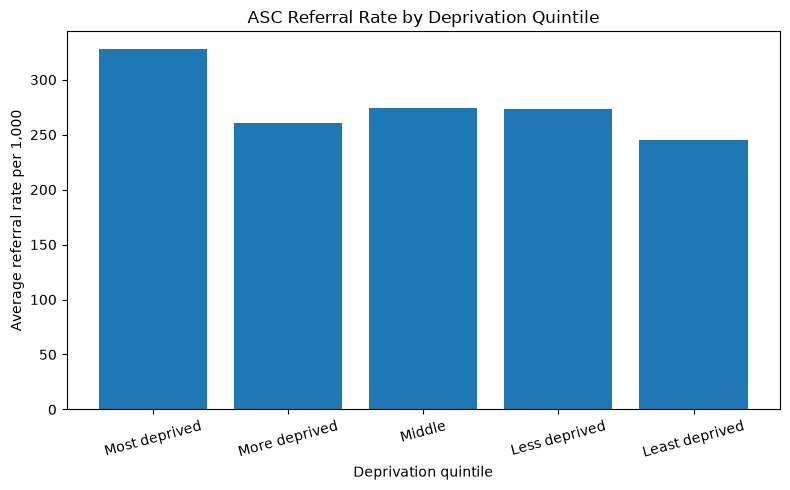

In [12]:
plt.figure(figsize=(8,5)) 
plt.bar(imd_summary['IMD_Quintile'], imd_summary['Referral_Rate_per_1000']) 
plt.title('ASC Referral Rate by Deprivation Quintile') 
plt.xlabel('Deprivation quintile') 
plt.ylabel('Average referral rate per 1,000') 
plt.xticks(rotation=15) 
plt.tight_layout() 

plt.savefig('../outputs/imd_vs_referrals.png') 

plt.show()

Inequality insight

The deprivation analysis identified a clear social gradient in Adult Social Care demand. Neighbourhoods in the most deprived quintile experienced referral rates 1.34 times higher than those in the least deprived quintile, suggesting that deprivation is associated with increased care needs and highlighting the importance of targeted, neighbourhood-based prevention and support.